Training an FNN neural network with scaled dataframe

In [133]:
!pip install keras
!pip install tensorflow
!pip install scikeras

Defaulting to user installation because normal site-packages is not writeable
distutils: /users/imbahndu/.local/lib/python3.9/site-packages
sysconfig: /users/imbahndu/.local/lib64/python3.9/site-packages
user = True
home = None
root = None
prefix = None
Defaulting to user installation because normal site-packages is not writeable
distutils: /users/imbahndu/.local/lib/python3.9/site-packages
sysconfig: /users/imbahndu/.local/lib64/python3.9/site-packages
user = True
home = None
root = None
prefix = None
Defaulting to user installation because normal site-packages is not writeable
distutils: /users/imbahndu/.local/lib/python3.9/site-packages
sysconfig: /users/imbahndu/.local/lib64/python3.9/site-packages
user = True
home = None
root = None
prefix = None


In [134]:
#Importing modules and librarie
import tensorflow.keras as keras
import pandas as pd
import numpy as np
from scikeras.wrappers import KerasClassifier

In [135]:
#Loading dataframe 
df = pd.read_csv("/users/imbahndu/Desktop/Columbia DBM/Typing dataset/nn.csv")


In [136]:
df

,Hand,HoldTime,Direction,LatencyTime,FlightTime,Parkinsons
0,-0.899739,-0.070336,-1.191473,-0.554165,-0.521748,True
1,-0.899739,-0.133282,-1.191473,0.612123,0.756299,True
2,-0.899739,-0.164554,-1.191473,-0.689112,-0.718710,True
3,-0.899739,-0.227098,-1.191473,0.163639,0.264839,True
4,1.111434,-0.133282,-0.318695,-0.778694,-0.767793,True
...,...,...,...,...,...,...
127518,-0.899739,-0.352186,-1.191473,-1.070409,-0.743251,True
127519,1.111434,-0.039064,-0.318695,-1.070409,-0.743251,True
127520,1.111434,-0.446404,1.426861,-1.384520,0.363005,True
127521,-0.899739,0.007844,0.554083,-1.384520,0.363005,True


In [ ]:
#Dropping the hand and direction columns since they might not be predictive
df = df.drop(columns = ["Hand", "Direction"])

In [137]:
df["Parkinsons"].isna().sum()

0

In [138]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [139]:
df["Parkinsons"].isna().sum()

0

In [140]:
df["Parkinsons"].value_counts()

Parkinsons
True     95042
False    32481
Name: count, dtype: int64

In [158]:
#Dividing into train_test_split and defining labels
df["Parkinsons"] = df["Parkinsons"].astype(int)

print(df["Parkinsons"].value_counts())

y = df["Parkinsons"]

X = df.drop(columns=["Parkinsons"])

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.4)



Parkinsons
1    95042
0    32481
Name: count, dtype: int64


In [142]:
#Making sure my featurs are int or floats
print(X_train.dtypes)

Hand           float64
HoldTime       float64
Direction      float64
LatencyTime    float64
FlightTime     float64
dtype: object


In [143]:
print(y)

0         1
1         1
2         1
3         1
4         1
         ..
127518    1
127519    1
127520    1
127521    1
127522    1
Name: Parkinsons, Length: 127523, dtype: int64


In [144]:
#Defining the loss function  and optimizer
loss_fn = keras.losses.BinaryCrossentropy(from_logits=False)

optim = keras.optimizers.SGD(learning_rate=0.01)


In [145]:
#Creating the NN Architecture 


nn_model = keras.Sequential()

#Input layer 
input_layer = keras.layers.InputLayer(input_shape = (len(X_train.columns),))
nn_model.add(input_layer)

#Hidden layer 1
hidden_layer_1 = keras.layers.Dense(units = 128, activation="relu")
nn_model.add(hidden_layer_1)

#Hidden layer 2
hidden_layer_2 = keras.layers.Dense(units=64, activation="relu")
nn_model.add(hidden_layer_2)

#hidden layer 3
hidden_layer_3 = keras.layers.Dense(units=32, activation="relu")
nn_model.add(hidden_layer_3)
dropout = keras.layers.Dropout(0.2)
nn_model.add(dropout)

#extra hidden layer 
hidden_layer_5 = keras.layers.Dense(units=16, activation="relu")
nn_model.add(hidden_layer_5)
nn_model.add(dropout)

#hidden layer 4 / output 5
hidden_layer_4 = keras.layers.Dense(units=1, activation="sigmoid")
nn_model.add(hidden_layer_4)


 #Compiling the model
nn_model.compile(optimizer=optim, loss=loss_fn, metrics=["accuracy"])



/users/imbahndu/.local/lib/python3.9/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [146]:
nn_model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_35 (Dense)                │ (None, 128)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,649 (45.50 KB)

 Trainable params: 11,649 (45.50 KB)

 Non-trainable params: 0 (0.00 B)

In [159]:
#Fitting the model
num_epochs = 50
model = nn_model.fit(X_train, y_train, epochs=num_epochs, validation_split=0.3, class_weight={0: 2, 1: 1})

Epoch 1/50
1674/1674 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.7363 - loss: 0.8353 - val_accuracy: 0.7422 - val_loss: 0.6032
Epoch 2/50
1674/1674 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7356 - loss: 0.8232 - val_accuracy: 0.7383 - val_loss: 0.6101
Epoch 3/50
1674/1674 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.7280 - loss: 0.8288 - val_accuracy: 0.7326 - val_loss: 0.6100
Epoch 4/50
1674/1674 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.7333 - loss: 0.8262 - val_accuracy: 0.7332 - val_loss: 0.6120
Epoch 5/50
1674/1674 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.7268 - loss: 0.8260 - val_accuracy: 0.7282 - val_loss: 0.6047
Epoch 6/50
1674/1674 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.7287 - loss: 0.8268 - val_accuracy: 0.7275 - val_loss: 0.6055
Epoch 7/50
1674/1674 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.7239 - loss: 0.8294 - val_accuracy: 0.7417 - val_loss: 0.5946
Epoch 8/50
1674/1674 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.7315 - loss: 0.

In [160]:
#Evaluating the model's accuracy and loss over time through visualizations
print(model.history.keys())
import matplotlib.pyplot as plt

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


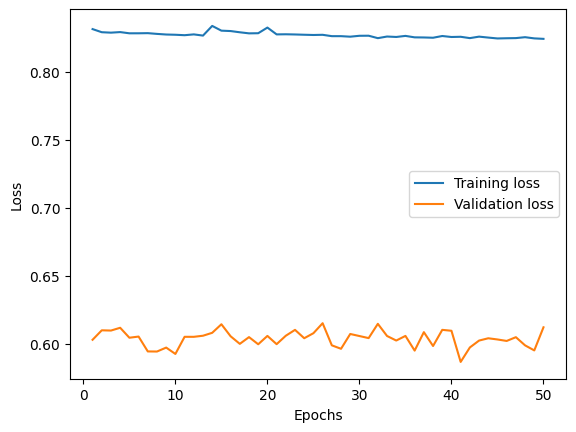

In [161]:
#Plotting loss 
plt.plot(range(1, num_epochs+1), model.history['loss'], label="Training loss")
plt.plot(range(1, num_epochs+1), model.history['val_loss'], label="Validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

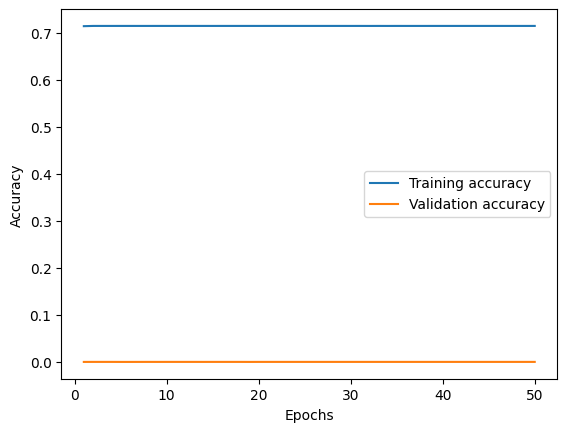

In [150]:
plt.plot(range(1, num_epochs+1), model.history['accuracy'], label="Training accuracy")
plt.plot(range(1, num_epochs+1), model.history['val_accuracy'], label="Validation accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [162]:
loss, accuracy = nn_model.evaluate(X_test,y_test)
print("Loss is ", loss)
print("Accuracy is", accuracy)

1595/1595 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7043 - loss: 0.6144
Loss is  0.6124698519706726
Accuracy is 0.7068613767623901


In [163]:
#Predictions on X_test and setting threshold to 0.3 
predict_label = nn_model.predict(X_test)
predict_label_int = (predict_label >= 0.3).astype(int)

1595/1595 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


In [166]:
#Confusion matrix and classification report 

print(confusion_matrix(y_test, predict_label_int))

print(classification_report(y_test, predict_label_int))

print(accuracy_score(y_test, predict_label_int))

[[    0 12957]
 [    2 38051]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00     12957
           1       0.75      1.00      0.85     38053

    accuracy                           0.75     51010
   macro avg       0.37      0.50      0.43     51010
weighted avg       0.56      0.75      0.64     51010

0.745951774161929


/tmp/ipykernel_1764766/78027907.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


<function matplotlib.pyplot.show(close=None, block=None)>

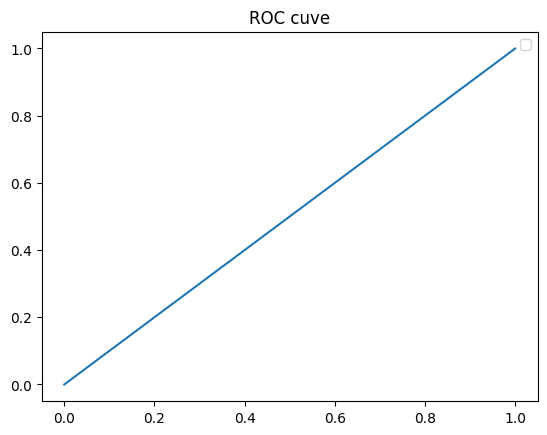

In [165]:
from sklearn.metrics import roc_curve
import seaborn as sns

fpr, tpr, threshold = roc_curve(y_test, predict_label_int)
sns.lineplot(x=fpr, y=tpr)
plt.title("ROC cuve")
plt.legend()
plt.show